In [1]:
import matplotlib.pyplot as plt 
import numpy as np
from playground import GridWorld, experiment
from mentalmodel import KripkeMM, KMMcompare

### Simple test and plotting function to test model

In [2]:
def plotlines(x_data: np.array, line_list: list[dict], title, xlabel, ylabel, labels_used=None):
    """
    Plot several liens at ones 
    Lines_dic format : [{"y": array, "label": "Name", "color": "color", "linetype": "type"}]
    """

    plt.figure(figsize=(8, 5))

    # get lines and l=plot them 
    for line in line_list:
        plt.plot(
            x_data,
            line["y"],
            label=line.get("label", "unnamed line"),
            color=line.get("color", None),
            linestyle=line.get("linetype", "-")
        )
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=":", alpha=0.6)

    if labels_used:
        labels_string = ", ".join(labels_used)
        text_to_display = f"Labels used:\n{labels_string}"
         # Place text below the X-axis (centered horizontally at 0.5, near bottom at 0.02)
        plt.figtext(0.1, 0.0, text_to_display, fontsize=10, color="#333333", horizontalalignment="left")

        # Shift the bottom of the graph up to make room
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.18) 

    plt.show()


def test(labeller_name, labelling_funct, epochs, compare=False, k=None, complex_labels=False):
    # simple experiment for intuition
    env = GridWorld(10, 3)
    action_map = env.actions
    model = KMMcompare(n_action=len(env.actions), labelling_function=labelling_funct, complex_labels=complex_labels)

    # run experiment using bisimulation 
    e_lengths, struct_size, meta_size = experiment(env, model, epochs, compare=compare, k=k)
    
    x_data = np.arange(len(struct_size))

    lines = [
        {"y": struct_size, "label": "Original states", "color": "black", "linetype": "-"},
        {"y": meta_size["bisim"], "label": "Macro Bisim", "color": "blue", "linetype": "--"},
            ]
    
    if compare:
        lines.append({"y": meta_size["k_bisim"], "label": "Macro k-Misim", "color": "red", "linetype": "-."},)


    # information needed for labelling plot 
    xlabel = "Epochs"
    ylabel = "Number of states"
    title = f"Model growth vs epochs ({labeller_name}) k = {k}"
    labels_used = list(set.union(*model.struct.labels.values()))

    # plot 
    plotlines(x_data, lines, title, xlabel, ylabel, labels_used=labels_used)

### Labelling functions to try out 

In [3]:
def no_rewards_labelling(self, s, action, next_s, reward, done):

    # add action
    self.labels[s].add(f"a{action}")

    # add bounds
    if s == next_s:
        self.labels[s].add("bounded")
    
    # label terminal states 
    if done:
        # create gaol label
        if reward > 0:
            self.labels[next_s].add("Goal")
        else:
            self.labels[next_s].add("TS")


def no_bounds_labelling(self, s, action, next_s, reward, done):
        # add action at current state 
        self.labels[s].add(f"a{action}")

        # labels at future state 
        self.labels[next_s].add(f"r_{reward}")
        
        # label terminal states 
        if done:
            # create gaol label
            if reward > 0:
                self.labels[next_s].add("Goal")
            else:
                self.labels[next_s].add("TS")

def no_actions_labelling(self, s, action, next_s, reward, done):
    # labels at future state 
    self.labels[next_s].add(f"r_{reward}")

    # add bounds
    if s == next_s:
        self.labels[s].add("bounded")
    
    # label terminal states 
    if done:
        # create gaol label
        if reward > 0:
            self.labels[next_s].add("Goal")
        else:
            self.labels[next_s].add("TS")

def env_labelling_multibounds(self, s, action, next_s, reward, done):

    # add actions bounds 
    if s == next_s:

        existing_bounds = {label for label in self.labels[s] if label.startswith("bound")}
        new_bound = f"bound_a{action}"

        if new_bound not in existing_bounds:
            self.labels[s].add(new_bound)

    # label terminal states 
    if done:
        # create gaol label
        if reward > 0:
            self.labels[next_s].add("Goal")
        else:
            self.labels[next_s].add("TS")
    # label nonterminal states
    else:
        self.labels[s].add("NTS")
        self.labels[next_s].add("NTS")

def env_labelling(self, s, action, next_s, reward, done):
    # add bounds
    if s == next_s:
        self.labels[s].add("bound")

    # label terminal states 
    if done:
        # create gaol label
        if reward > 0:
            self.labels[next_s].add("Goal")
        else:
            self.labels[next_s].add("TS")
    # label non terminal states
    else:
        self.labels[s].add("NTS")
        self.labels[next_s].add("NTS")


----------------------------------------------------------------------------------------------------


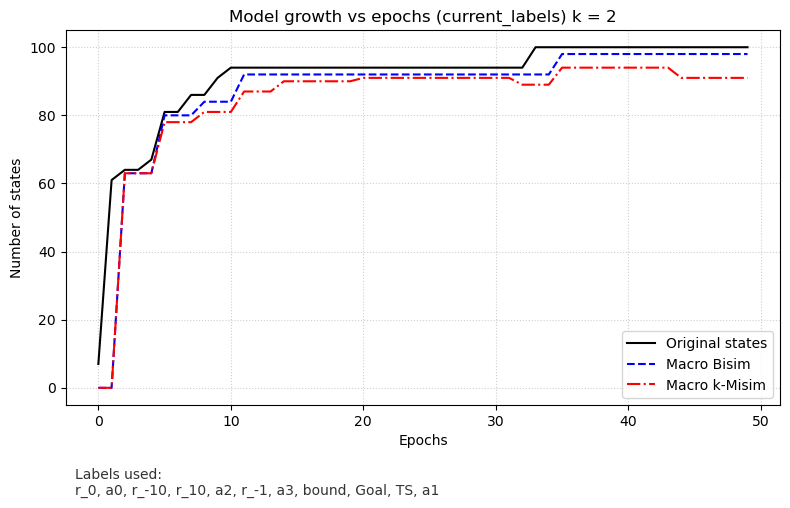

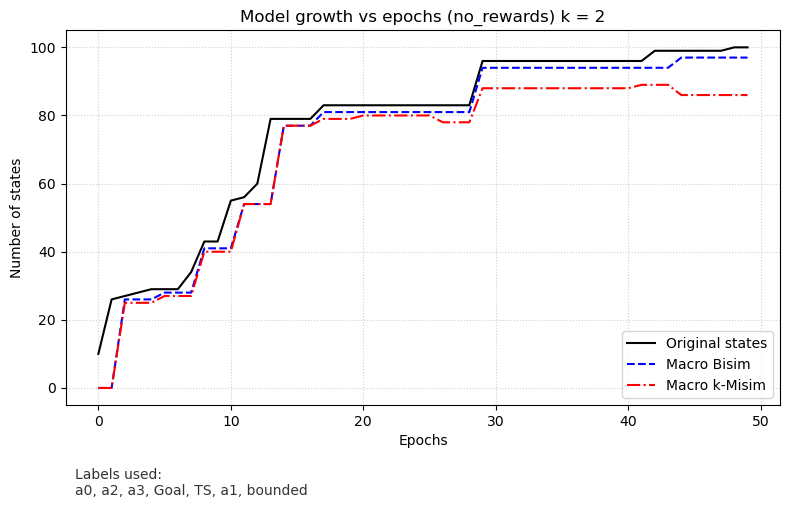

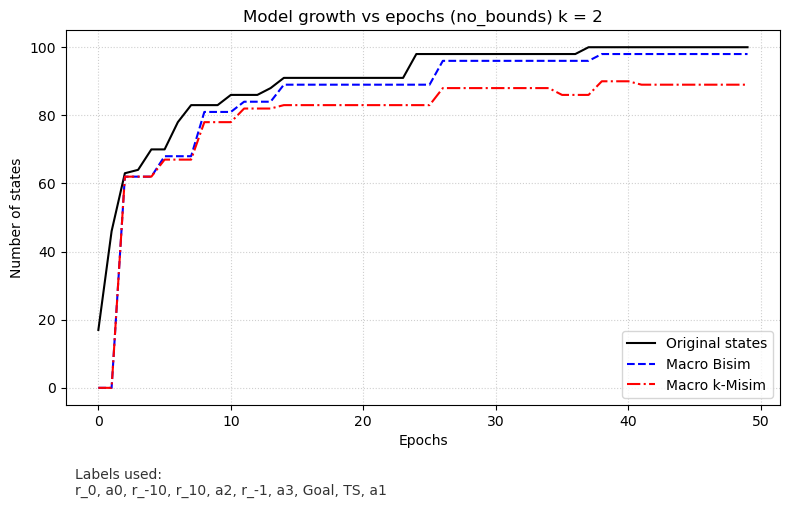

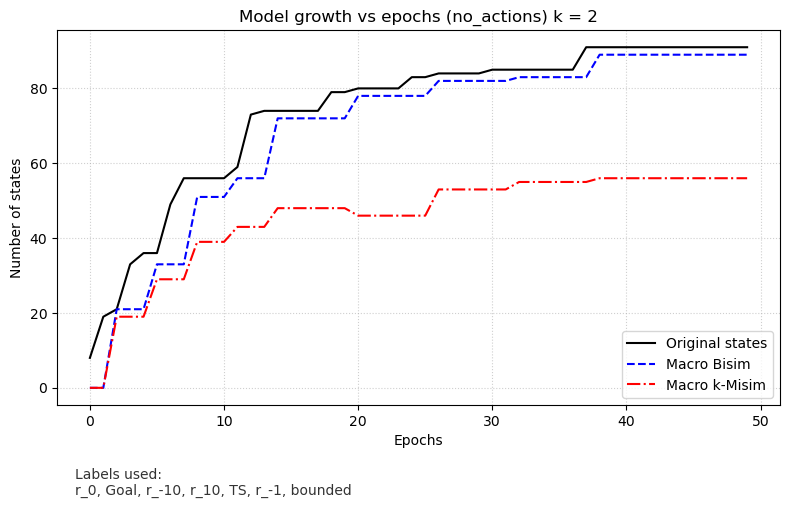

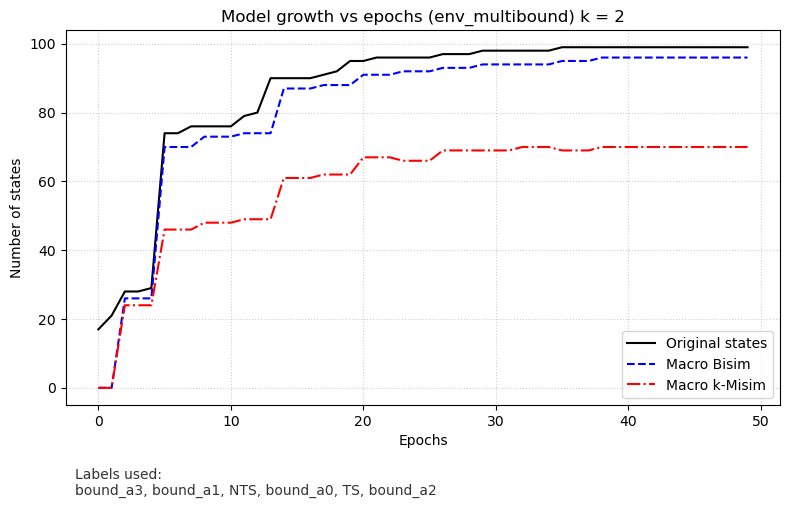

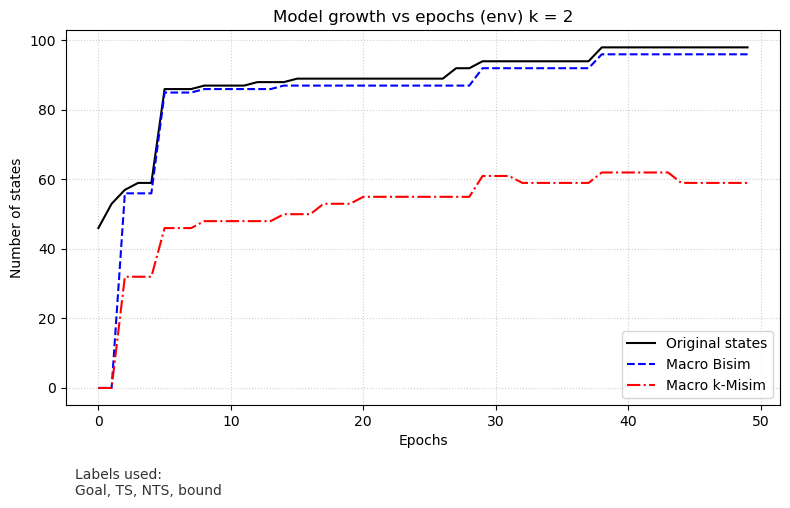

----------------------------------------------------------------------------------------------------


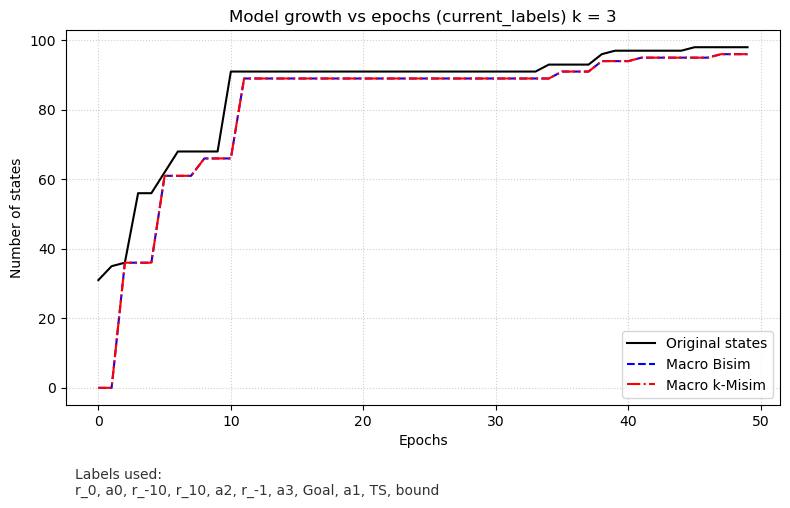

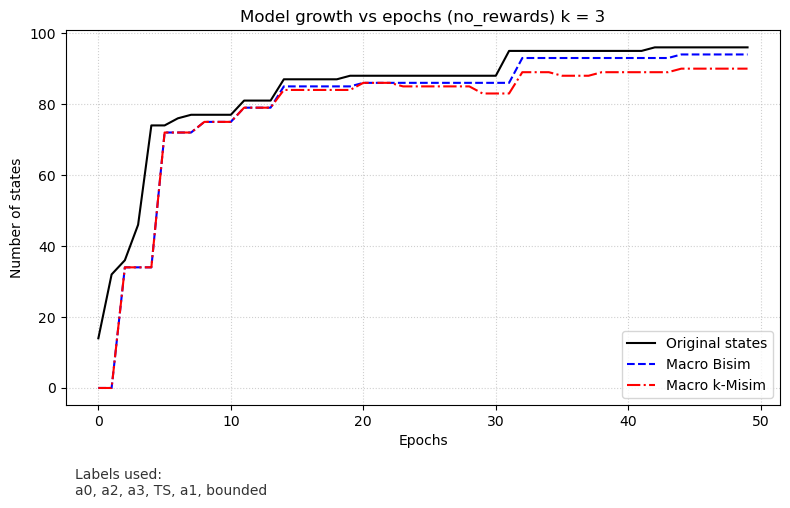

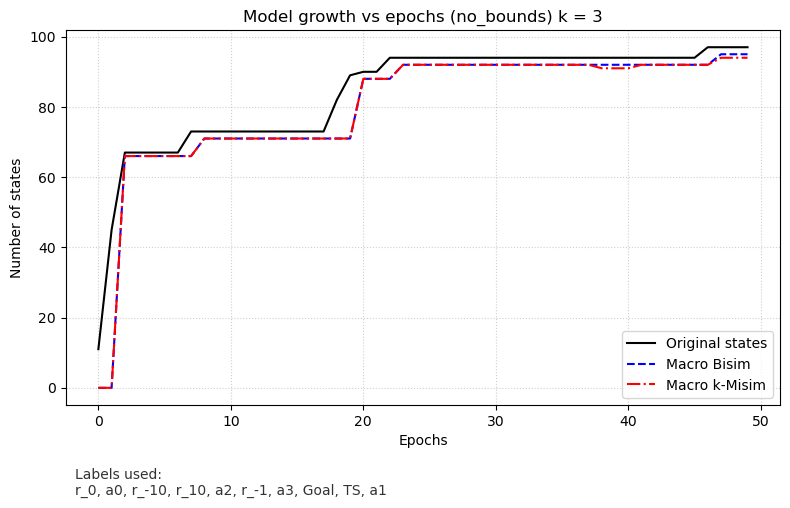

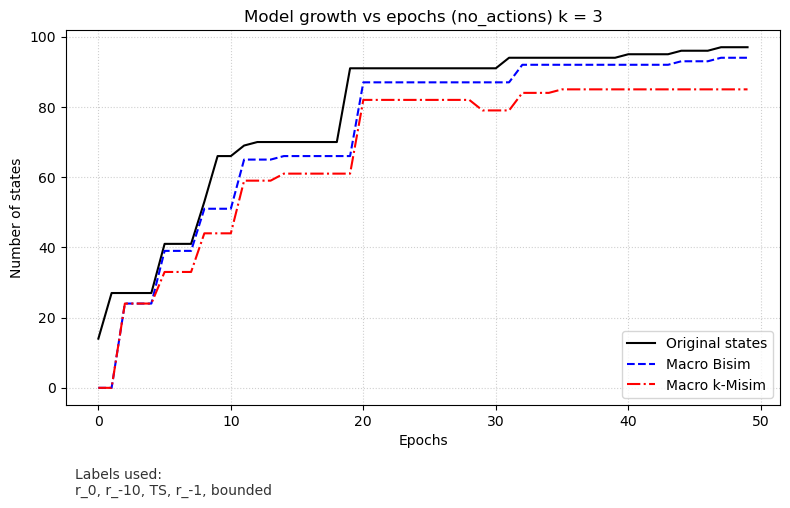

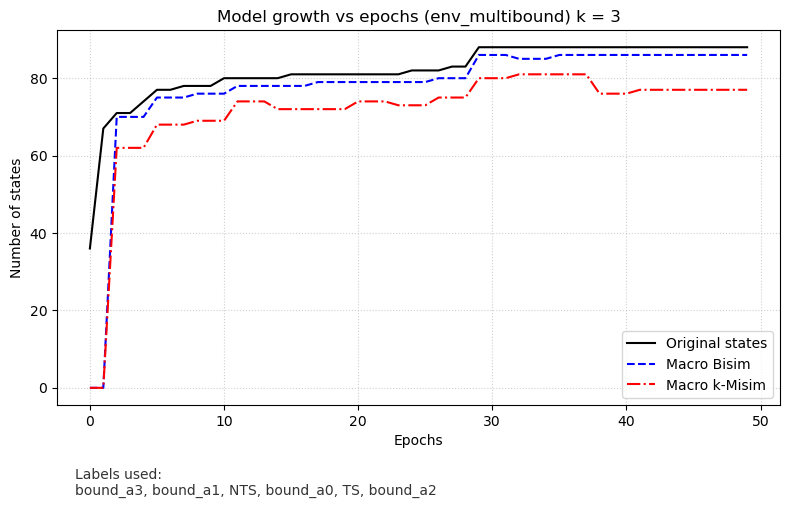

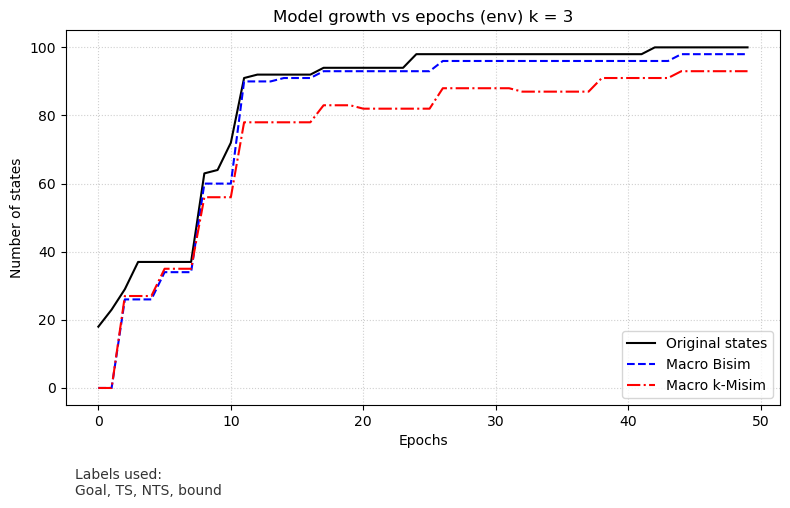

----------------------------------------------------------------------------------------------------


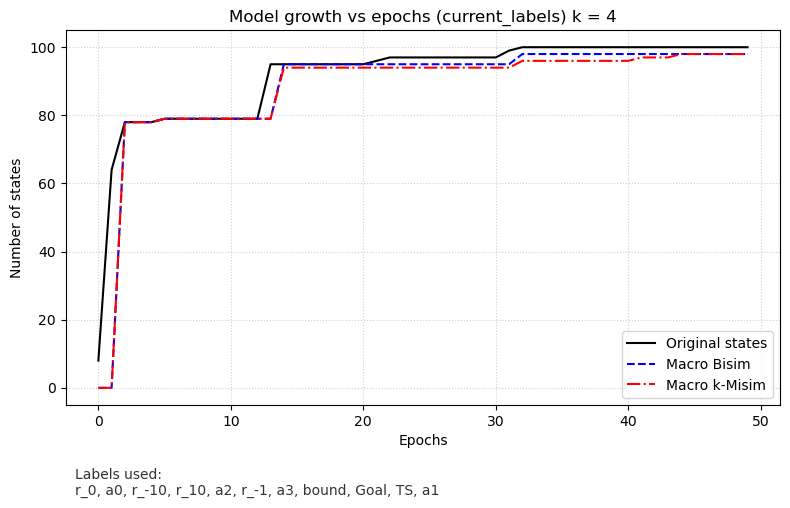

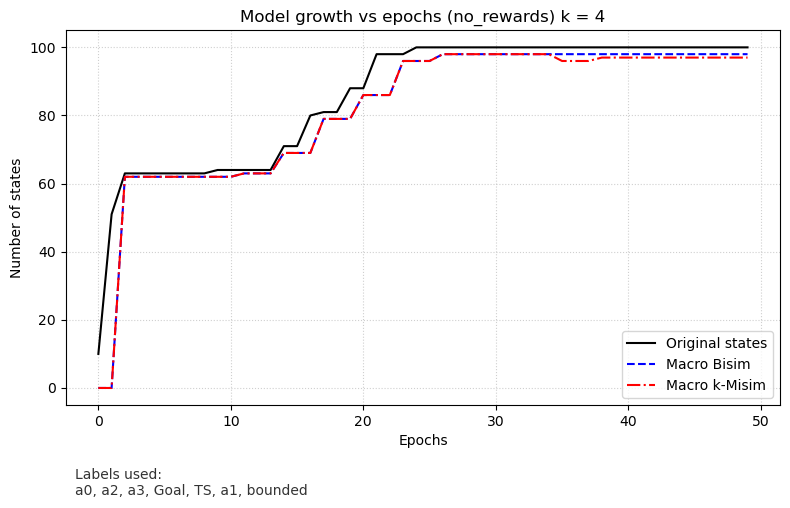

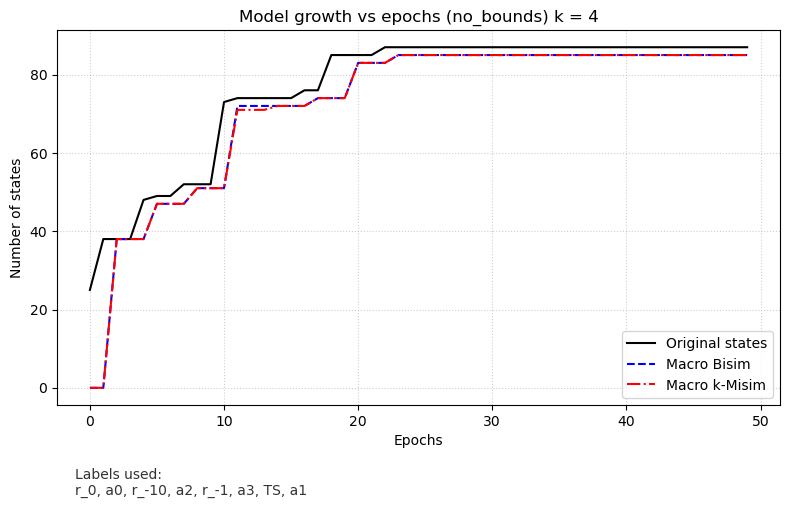

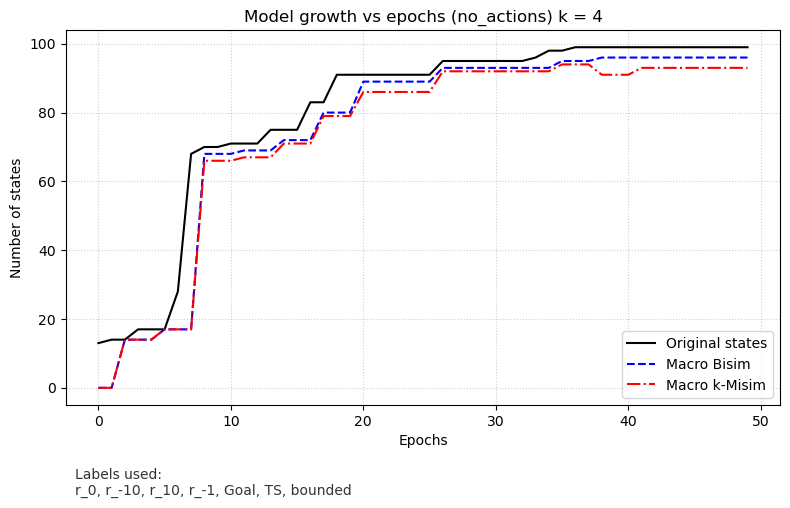

In [ ]:
## Testing labelling functions without complex labels 
labelling_functions = {
    "current_labels": None,
    "no_rewards": no_rewards_labelling,
    "no_bounds": no_bounds_labelling,
    "no_actions": no_actions_labelling,
    "env_multibound": env_labelling_multibounds,
    "env": env_labelling
}
for k in range(2, 6):
    print("--"*50)
    for labeler_name, labelling_func in labelling_functions.items():
        test(labeler_name, labelling_func, 50, compare=True, k=k, complex_labels=False)
